# Module 06 — Equilibria, stability & periodic orbits

Trajectories are what a system *does*; **invariant sets** are what a system *is*. An
attractor's skeleton — its fixed points, its unstable saddles, its periodic orbits — is
the scaffold every trajectory is draped over. Find that skeleton and classify it, and you
understand the dynamics before you've integrated a single long run.

In this module we locate equilibria and periodic orbits with `tsdynamics`, then read their
**linear stability** straight off the eigenvalues of the Jacobian. The rule is the same one
you already know from paper-and-pencil analysis — for a flow, stability is $\mathrm{Re}\,\lambda < 0$;
for a map it is $|\lambda| < 1$ — and the library computes the Jacobian for you.

**You will learn to:**
- Find all equilibria of a **flow** with `fixed_points(system, region=Box(...))`.
- Classify each with `fp.stable`, `fp.eigenvalues`, and read node / saddle / spiral from them.
- Find **map** fixed points (Newton, plus `method="sd"/"dl"` for unstable ones and the rigorous `method="interval"`).
- Compute **periodic orbits**: `periodic_orbits` for maps, `periodic_orbit` (single shooting) for flows, with Floquet multipliers.
- Estimate a signal's period with `estimate_period` to seed a shooting search.

*Estimated time: 30 min.*

In [1]:
# Colab/first-run setup: install the workshop stack if tsdynamics is missing.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly", "pandas"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import tsdynamics as ts
from tsdynamics.data import Box

print("tsdynamics", ts.__version__)

tsdynamics 5.3.1


## 1. Equilibria of a flow: the Lorenz skeleton

For a flow $\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x})$, an equilibrium (fixed point) is a
point where the vector field vanishes: $\mathbf{f}(\mathbf{x}^\*) = 0$. The Lorenz system

$$\dot x = \sigma(y-x), \qquad \dot y = x(\rho - z) - y, \qquad \dot z = xy - \beta z$$

has three: the origin, and the symmetric pair $C^\pm$ that sit at the centres of the two
"wings" of the butterfly. `fixed_points` finds them by multi-start Newton on the analytic
Jacobian (which the library auto-generates). For a **flow you must supply a search `region`**
— a `Box(lo, hi)` bounding where to look.

In [2]:
lor = ts.Lorenz()
region = Box(np.array([-30.0, -30.0, 0.0]), np.array([30.0, 30.0, 50.0]))

fps = ts.fixed_points(lor, region=region, n_seeds=200)
print(fps.summary())

FixedPointSet — 3 items  (Lorenz)
  FixedPoint([-8.485281 -8.485281 27.      ], unstable, Re(λ)max=+0.0940)
  FixedPoint([ 0.  0. -0.], unstable, Re(λ)max=+11.8277)
  FixedPoint([ 8.485281  8.485281 27.      ], unstable, Re(λ)max=+0.0940)


All three land where the textbook says. The origin is the classic **saddle**; the
off-centre pair $C^\pm$ each carry a real negative eigenvalue plus a complex conjugate pair
with a *tiny positive* real part — the outward spiral that flings trajectories from one wing
to the other and makes the attractor chaotic. Let's read the eigenvalues directly.

In [3]:
for fp in fps:
    kind = "STABLE" if fp.stable else "unstable"
    print(f"x* = {np.round(fp.x, 3)}   [{kind}]")
    print(f"    eigenvalues: {np.round(fp.eigenvalues, 4)}")

x* = [-8.485 -8.485 27.   ]   [unstable]
    eigenvalues: [-13.8546 +0.j       0.094 +10.1945j   0.094 -10.1945j]
x* = [ 0.  0. -0.]   [unstable]
    eigenvalues: [-22.8277+0.j  11.8277+0.j  -2.6667+0.j]
x* = [ 8.485  8.485 27.   ]   [unstable]
    eigenvalues: [-13.8546 +0.j       0.094 +10.1945j   0.094 -10.1945j]


**Reading stability off the spectrum (flows: $\mathrm{Re}\,\lambda < 0$ ⇒ attracting):**

- **Origin** — eigenvalues are all *real*, one strongly positive ($\approx +11.8$) and two
  negative. Positive + negative real eigenvalues ⇒ a **saddle**: attracting along some
  directions, repelling along others.
- **$C^\pm$** — one real negative eigenvalue and a **complex pair** $0.094 \pm 10.2i$. A
  complex pair means *rotation*; its real part sets whether the spiral winds in or out. Here
  $\mathrm{Re}\,\lambda = +0.094 > 0$ (just barely) ⇒ an **unstable spiral**. That whisker of
  positive real part is the engine of Lorenz chaos.

Every fixed point on the Lorenz attractor is unstable — which is exactly why the flow never
settles onto any of them and keeps roaming instead.

### Visualising the skeleton

Overlay the three equilibria on a chunk of the attractor. You can see $C^\pm$ nestled in the
eyes of the two wings, with the origin's saddle sitting on the axis between them.

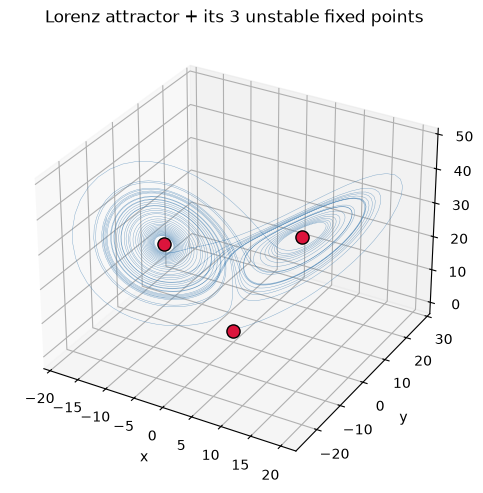

In [4]:
traj = lor.integrate(final_time=40.0, dt=0.01, backend="jit")

fig = plt.figure(figsize=(6.5, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot(traj.y[:, 0], traj.y[:, 1], traj.y[:, 2], lw=0.3, color="steelblue", alpha=0.7)
for fp in fps:
    ax.scatter(*fp.x, s=90, color="crimson", edgecolor="k", depthshade=False, zorder=5)
ax.set(xlabel="x", ylabel="y", zlabel="z", title="Lorenz attractor + its 3 unstable fixed points")
plt.tight_layout()
plt.show()

### The eigenvalue plane

`FixedPointSet.eigenvalue_plane()` plots every eigenvalue in the complex plane — the single
most useful stability diagnostic. For a **flow** the dividing line is the imaginary axis:
eigenvalues to the **left** ($\mathrm{Re}\,\lambda < 0$) are stable directions, to the
**right** unstable. Notice the two $C^\pm$ conjugate pairs sitting just barely into the right
half-plane.

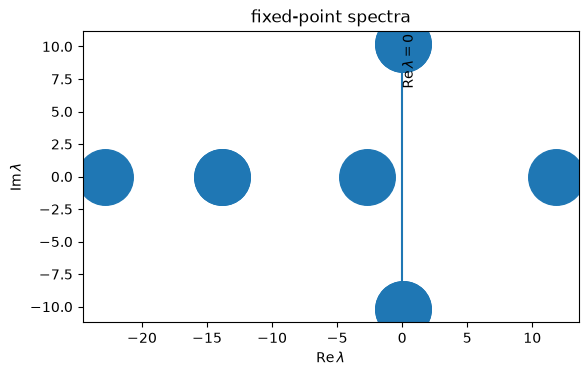

In [5]:
from IPython.display import display

# .plot() on a result's spec returns a standalone matplotlib Figure — display it directly.
display(fps.eigenvalue_plane().plot())

## 2. Map fixed points and the unit circle

For a map $\mathbf{x}_{n+1} = \mathbf{F}(\mathbf{x}_n)$ a fixed point satisfies
$\mathbf{F}(\mathbf{x}^\*) = \mathbf{x}^\*$, and the stability test changes: an eigenvalue
(multiplier) $\lambda$ is stable when it lies **inside the unit circle**, $|\lambda| < 1$.
The Hénon map

$$x_{n+1} = 1 - a\,x_n^2 + y_n, \qquad y_{n+1} = b\,x_n$$

has two fixed points, both saddles — one multiplier outside the circle, one inside.

In [6]:
henon = ts.Henon()
hen_region = Box(np.array([-2.0, -2.0]), np.array([2.0, 2.0]))

# method="interval" (rigorous Krawczyk) needs a region and finds ALL roots — it cannot
# silently miss one the way multi-start Newton can.
hfps = ts.fixed_points(henon, region=hen_region, method="interval")
for fp in hfps:
    kind = "STABLE" if fp.stable else "unstable (saddle)"
    print(f"x* = {np.round(fp.x, 4)}   |λ| = {np.round(np.abs(fp.eigenvalues), 4)}   [{kind}]")

x* = [-1.1314 -0.3394]   |λ| = [3.2598 0.092 ]   [unstable (saddle)]
x* = [0.6314 0.1894]   |λ| = [1.9237 0.1559]   [unstable (saddle)]


Both have one multiplier with $|\lambda| > 1$ (the unstable direction) and one with
$|\lambda| < 1$ (the stable direction) — the signature of a **saddle**. The unstable
manifolds of these two saddles, tangled together, *are* the Hénon attractor.

On the eigenvalue plane a **map**'s reference curve is the **unit circle**, not the imaginary
axis: a point is stable iff every multiplier sits strictly inside it.

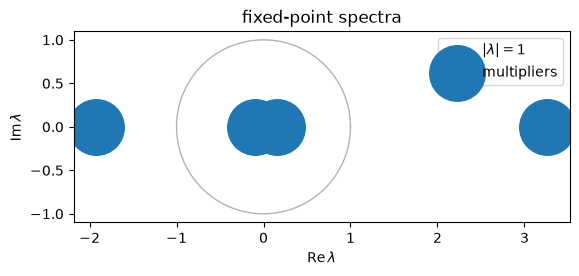

In [7]:
display(hfps.eigenvalue_plane().plot())

### Reaching *unstable* orbits: `method="sd"` / `"dl"`

Plain Newton converges to whatever root is nearest a seed, but strongly unstable fixed points
have tiny basins of attraction under Newton and are easy to miss. The **Schmelcher–Diakonos**
(`method="sd"`) and **Davidchack–Lai** (`method="dl"`) transformations stabilise the
iteration so it can land on unstable points reliably. For the chaotic logistic map
$x_{n+1} = r\,x_n(1-x_n)$ at $r = 3.9$ both fixed points are unstable, yet `sd` finds them.

In [8]:
log = ts.Logistic().with_params(r=3.9)  # set a control parameter with with_params
newton_fps = ts.fixed_points(log)
sd_fps = ts.fixed_points(log, method="sd", n_seeds=100)
print(f"newton found {len(list(newton_fps))} fixed point(s); sd found {len(list(sd_fps))}")
for fp in newton_fps:
    print(f"  x* = {float(fp.x[0]):+.4f}   multiplier λ = {complex(fp.eigenvalues[0]):+.4f}   "
          f"{'stable' if fp.stable else 'unstable'}")

newton found 2 fixed point(s); sd found 2
  x* = -0.0000   multiplier λ = +3.9000+0.0000j   unstable
  x* = +0.7436   multiplier λ = -1.9000+0.0000j   unstable


The nonzero fixed point $x^\* = 1 - 1/r \approx 0.744$ has multiplier $\lambda = 2 - r = -1.9$;
$|\lambda| = 1.9 > 1$, so it is unstable — as it must be, because the logistic map is chaotic
at $r = 3.9$ and has no stable orbits.

## 3. Periodic orbits of a map

A period-$p$ orbit of a map is a fixed point of the $p$-times-iterated map $\mathbf{F}^p$.
`periodic_orbits(map, p)` finds them (Davidchack–Lai by default), filters to the minimal
("prime") period, and de-duplicates cyclic shifts. Its stability comes from the product of
Jacobians around the cycle — the orbit's **multipliers**.

Take the logistic map just past its first period-doubling, at $r = 3.2$. The period-1 fixed
point has gone unstable and a **stable period-2 orbit** has been born.

In [9]:
log32 = ts.Logistic().with_params(r=3.2)
orbits2 = ts.periodic_orbits(log32, 2)
print(f"period-2 orbits at r=3.2: {len(list(orbits2))}")
for o in orbits2:
    pts = np.round(o.points.ravel(), 4)
    print(f"  cycle {pts}   multiplier = {np.round(o.multipliers, 4)}   "
          f"{'STABLE' if o.stable else 'unstable'}")

period-2 orbits at r=3.2: 1
  cycle [0.7995 0.513 ]   multiplier = [0.16+0.j]   STABLE


The orbit hops between $x \approx 0.513$ and $x \approx 0.799$ with multiplier $|\lambda| = 0.16 < 1$
— **stable**, exactly the attracting 2-cycle you'd see as two branches in a bifurcation
diagram (Module 03). Push $r$ into the chaotic regime and every periodic orbit turns unstable
— including the famous **period-3** window that, by Sharkovskii's theorem, guarantees orbits
of every period.

In [10]:
log39 = ts.Logistic().with_params(r=3.9)
orbits3 = ts.periodic_orbits(log39, 3)
print(f"period-3 orbits at r=3.9: {len(list(orbits3))}")
for o in orbits3:
    print(f"  cycle {np.round(o.points.ravel(), 4)}   multiplier = {np.round(o.multipliers, 4)}   "
          f"{'stable' if o.stable else 'UNSTABLE'}")

period-3 orbits at r=3.9: 2
  cycle [0.9512 0.181  0.5781]   multiplier = [5.3347+0.j]   UNSTABLE
  cycle [0.9647 0.1327 0.4487]   multiplier = [-4.1547+0.j]   UNSTABLE


Both period-3 orbits have $|\lambda| > 1$: they are unstable, buried inside the chaotic
attractor. Unstable periodic orbits like these are the raw material of orbit-based control
(OGY) and of periodic-orbit theory.

## 4. Periodic orbits of a flow: single shooting + Floquet multipliers

A limit cycle of a flow is a closed orbit of some period $T$. `periodic_orbit` locates one by
**single shooting**: it solves for an initial point $\mathbf{x}_0$ and a period $T$ such that
the flow returns exactly, $\boldsymbol{\phi}_T(\mathbf{x}_0) = \mathbf{x}_0$, using a bordered
Newton step on the monodromy matrix. The eigenvalues of that matrix are the **Floquet
multipliers**; a limit cycle always has one trivial multiplier $\approx 1$ (the direction
*along* the flow), and the cycle is stable iff every *other* multiplier has $|\lambda| < 1$.

The Rössler system at $c = 2.5$ sits in a clean period-1 window. We first land on the cycle
by integrating away the transient, then read off a period estimate to seed the shooting.

In [11]:
ros = ts.Rossler().with_params(c=2.5)
warmup = ros.integrate(final_time=60.0, dt=0.02, backend="jit")
seed_point = warmup.y[-1]                       # a point sitting on the limit cycle

# estimate_period reads the dominant period straight from a scalar signal (autocorrelation)
T_est = ts.estimate_period(warmup.y[:, 0], dt=0.02).value
print(f"seed point on cycle: {np.round(seed_point, 3)},  period estimate T ≈ {T_est:.3f}")

seed point on cycle: [-1.632  2.895  0.58 ],  period estimate T ≈ 5.817


In [12]:
po = ts.periodic_orbit(ros, ic=seed_point, period_guess=float(T_est),
                       steps_per_period=600, n_points=200)
print(f"converged period T = {po.period:.4f}")
print(f"Floquet multipliers = {np.round(po.multipliers, 4)}")
print(f"orbit is {'STABLE' if po.stable else 'unstable'}")

converged period T = 5.7490
Floquet multipliers = [ 1.    +0.j -0.7697+0.j -0.    +0.j]
orbit is STABLE


The shooting nails $T \approx 5.75$. One multiplier is $\approx 1$ (the trivial along-flow
direction), and the non-trivial one is $\lambda \approx -0.77$ with $|\lambda| < 1$ — so this
is a **stable limit cycle** (an attracting periodic orbit). The negative sign says the cycle
is approached with a half-turn flip each period.

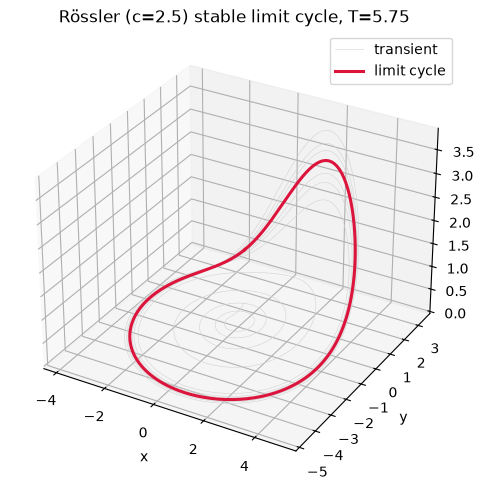

In [13]:
fig4 = plt.figure(figsize=(6.5, 5))
ax = fig4.add_subplot(111, projection="3d")
ax.plot(warmup.y[:, 0], warmup.y[:, 1], warmup.y[:, 2], lw=0.4, color="lightgray", label="transient")
pts = np.asarray(po.points)
ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], lw=2.2, color="crimson", label="limit cycle")
ax.set(xlabel="x", ylabel="y", zlabel="z", title=f"Rössler (c=2.5) stable limit cycle, T={po.period:.2f}")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Foreshadowing the capstone: node + saddle in a bistable well

The capstone ("Guardian of the Grid") lives or dies on the stability of a power-grid node,
and the governing physics is a **bistable** double-well: two attracting operating states
separated by an unstable saddle. That structure is universal — here is the simplest system
with exactly that skeleton, a damped particle in a double-well potential
$V(x) = -\tfrac12\beta x^2 + \tfrac14 x^4$:

$$\dot x = v, \qquad \dot v = -\delta v + \beta x - x^3.$$

We build it with the custom-system pattern from Module 02 (staticmethod `_equations`,
`dim=`, symengine), then find and classify its equilibria.

In [14]:
import symengine as se

class DoubleWellFlow(ts.ContinuousSystem):
    """Damped particle in a symmetric double well — a minimal bistable flow."""
    params = {"delta": 0.3, "beta": 1.0}
    dim = 2
    variables = ("x", "v")
    default_ic = [0.5, 0.0]

    @staticmethod
    def _equations(y, t, *, delta, beta):
        x, v = y(0), y(1)
        return [v, -delta * v + beta * x - x**3]

dw = DoubleWellFlow()
dw_region = Box(np.array([-2.0, -2.0]), np.array([2.0, 2.0]))
dw_fps = ts.fixed_points(dw, region=dw_region)
print(dw_fps.summary())
for fp in dw_fps:
    print(f"  x* = {np.round(fp.x, 3)}   eigenvalues {np.round(fp.eigenvalues, 3)}   "
          f"[{'STABLE node/spiral' if fp.stable else 'SADDLE'}]")

FixedPointSet — 3 items  (DoubleWellFlow)
  FixedPoint([-1.  0.], stable, Re(λ)max=-0.1500)
  FixedPoint([0. 0.], unstable, Re(λ)max=+0.8612)
  FixedPoint([1. 0.], stable, Re(λ)max=-0.1500)


  x* = [-1.  0.]   eigenvalues [-0.15+1.406j -0.15-1.406j]   [STABLE node/spiral]
  x* = [0. 0.]   eigenvalues [ 0.861+0.j -1.161+0.j]   [SADDLE]
  x* = [1. 0.]   eigenvalues [-0.15+1.406j -0.15-1.406j]   [STABLE node/spiral]


Three equilibria, exactly as the potential demands: two **stable spirals** at the well
bottoms $x = \pm 1$ (both eigenvalues have $\mathrm{Re}\,\lambda < 0$) and an **unstable
saddle** at the barrier top $x = 0$ (one positive, one negative real eigenvalue). Which well a
trajectory falls into is decided by which side of the saddle's stable manifold it starts on —
and *that* boundary between the two basins is the object we'll map and defend in the capstone
(Module 07 builds the basin picture explicitly).

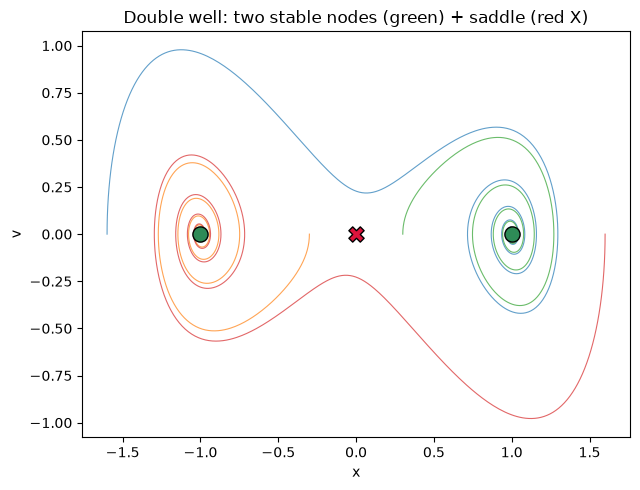

In [15]:
fig5, ax5 = plt.subplots(figsize=(6.5, 5))
# a few trajectories settling into the two wells
for x0 in (-1.6, -0.3, 0.3, 1.6):
    tr = dw.integrate(final_time=40.0, dt=0.02, ic=[x0, 0.0], backend="jit")
    ax5.plot(tr.y[:, 0], tr.y[:, 1], lw=0.8, alpha=0.7)
for fp in dw_fps:
    ax5.scatter(*fp.x, s=120,
                color=("seagreen" if fp.stable else "crimson"),
                marker=("o" if fp.stable else "X"),
                edgecolor="k", zorder=5)
ax5.set(xlabel="x", ylabel="v", title="Double well: two stable nodes (green) + saddle (red X)")
plt.tight_layout()
plt.show()

## 🧪 Exercises

Fill in each starter cell. Solutions are worked at the bottom — try first!

**Exercise 1 — Equilibria & stability of a catalogue flow.**
Find the fixed points of the **Thomas** attractor (`ts.Thomas()`) inside the box
$[-5, 5]^3$. Print each location, whether it is stable, and its eigenvalues. How many
equilibria are there, and are any of them stable?

*Hint:* the pattern is `ts.fixed_points(sys, region=Box(lo, hi))`; iterate the returned set
and read `fp.x`, `fp.stable`, `fp.eigenvalues`. Print `fps.summary()` for a quick overview.

In [16]:
thomas = ts.Thomas()
# region = Box(np.array([...]), np.array([...]))
# fps_t = ts.fixed_points(...)
# YOUR CODE HERE

**Exercise 2 — Unstable map fixed points with `sd`/`dl`.**
The **Hénon** map's two fixed points are both saddles. Confirm you can recover *both* with
the default Newton solver, then again with `method="dl"`. Print their locations and the
magnitudes $|\lambda|$ of their multipliers, and check that each has one multiplier inside and
one outside the unit circle.

*Hint:* `ts.fixed_points(ts.Henon(), region=Box(...), method="dl")`. Use
`np.abs(fp.eigenvalues)` for the magnitudes.

In [17]:
henon2 = ts.Henon()
# hen_region = Box(np.array([-2.0, -2.0]), np.array([2.0, 2.0]))
# YOUR CODE HERE

**Exercise 3 — Period of an oscillation.**
Integrate the **Rössler** system at its default (chaotic) parameters is messy — instead use
the clean period-1 cycle at `c=2.5` you saw above. Integrate it, then use `estimate_period`
to read the dominant period of the `x` component. Does it match the shooting result $T \approx 5.75$?

*Hint:* `ros = ts.Rossler().with_params(c=2.5)`, integrate with `final_time=60, dt=0.02`,
then `ts.estimate_period(traj.y[:, 0], dt=0.02).value`.

In [18]:
# ros = ts.Rossler().with_params(c=2.5)
# YOUR CODE HERE

**Exercise 4 — A stable period-4 orbit of the logistic map.**
At $r = 3.5$ the logistic map has completed a *second* period doubling: its attractor is a
**stable period-4 cycle**. Find it with `periodic_orbits(map, 4)`, print the four points and
the multiplier, and confirm $|\lambda| < 1$ (stable).

*Hint:* `ts.Logistic().with_params(r=3.5)`, then `ts.periodic_orbits(log35, 4)`. The orbit's
points are `o.points`, its stability `o.multipliers` / `o.stable`.

In [19]:
# log35 = ts.Logistic().with_params(r=3.5)
# YOUR CODE HERE

## ✅ Solutions

### Solution 1

In [20]:
thomas = ts.Thomas()
region_t = Box(np.array([-5.0, -5.0, -5.0]), np.array([5.0, 5.0, 5.0]))
fps_t = ts.fixed_points(thomas, region=region_t, n_seeds=200)
print(fps_t.summary())
for fp in fps_t:
    print(f"  x* = {np.round(fp.x, 3)}   stable={fp.stable}   eigs={np.round(fp.eigenvalues, 3)}")
n_stable = sum(1 for fp in fps_t if fp.stable)
print(f"\n{len(list(fps_t))} equilibria; {n_stable} stable.")
# The origin is (near) an equilibrium of Thomas; at the standard b it is unstable, which is
# why the flow is chaotic and never settles onto it.

FixedPointSet — 27 items  (Thomas)
  FixedPoint([-3.867986 -2.344142  3.59015 ], unstable, Re(λ)max=+2.0390)
  FixedPoint([-3.795038 -0.778317  3.286084], unstable, Re(λ)max=+6.3902)
  FixedPoint([-3.59015   3.867986  2.344142], unstable, Re(λ)max=+2.0390)
  FixedPoint([-3.286084  3.795038  0.778317], unstable, Re(λ)max=+6.3902)
  FixedPoint([-3.120483 -0.615405 -0.114097], unstable, Re(λ)max=+2.8129)
  FixedPoint([-3.050898 -2.541867 -0.489569], unstable, Re(λ)max=+7.1357)
  FixedPoint([-2.632852 -2.632852 -2.632852], unstable, Re(λ)max=+2.5168)
  FixedPoint([-2.541867 -0.489569 -3.050898], unstable, Re(λ)max=+7.1357)
  FixedPoint([-2.344142  3.59015  -3.867986], unstable, Re(λ)max=+2.0390)
  FixedPoint([-0.778317  3.286084 -3.795038], unstable, Re(λ)max=+6.3902)
  FixedPoint([-0.615405 -0.114097 -3.120483], unstable, Re(λ)max=+2.8129)
  FixedPoint([-0.489569 -3.050898 -2.541867], unstable, Re(λ)max=+7.1357)
  FixedPoint([-0.114097 -3.120483 -0.615405], unstable, Re(λ)max=+2.8129)
  F

### Solution 2

In [21]:
henon2 = ts.Henon()
hen_region = Box(np.array([-2.0, -2.0]), np.array([2.0, 2.0]))
# The stabilised (DL) search transiently probes large x where the Hénon map overflows —
# harmless for the root finder, so we silence that transient RuntimeWarning.
for solver in ("newton", "dl"):
    print(f"method = {solver!r}:")
    with np.errstate(over="ignore", invalid="ignore"):
        hfps2 = ts.fixed_points(henon2, region=hen_region, method=solver)
    for fp in hfps2:
        mags = np.abs(fp.eigenvalues)
        inside = np.sum(mags < 1.0)
        outside = np.sum(mags > 1.0)
        print(f"    x* = {np.round(fp.x, 4)}   |λ| = {np.round(mags, 4)}   "
              f"({inside} inside, {outside} outside unit circle) -> saddle")

method = 'newton':
    x* = [-1.1314 -0.3394]   |λ| = [3.2598 0.092 ]   (1 inside, 1 outside unit circle) -> saddle
    x* = [0.6314 0.1894]   |λ| = [1.9237 0.1559]   (1 inside, 1 outside unit circle) -> saddle
method = 'dl':


    x* = [-1.1314 -0.3394]   |λ| = [3.2598 0.092 ]   (1 inside, 1 outside unit circle) -> saddle
    x* = [0.6314 0.1894]   |λ| = [1.9237 0.1559]   (1 inside, 1 outside unit circle) -> saddle


### Solution 3

In [22]:
ros = ts.Rossler().with_params(c=2.5)
traj = ros.integrate(final_time=60.0, dt=0.02, backend="jit")
T = ts.estimate_period(traj.y[:, 0], dt=0.02).value
print(f"estimated period from x(t): T = {T:.3f}")
print(f"single-shooting period (section 4): T = 5.749")
print(f"agreement: within {abs(T - 5.749):.3f} time units — same limit cycle.")

estimated period from x(t): T = 5.787
single-shooting period (section 4): T = 5.749
agreement: within 0.038 time units — same limit cycle.


### Solution 4

In [23]:
log35 = ts.Logistic().with_params(r=3.5)
orbits4 = ts.periodic_orbits(log35, 4)
print(f"period-4 orbits at r=3.5: {len(list(orbits4))}")
for o in orbits4:
    pts = np.sort(o.points.ravel())
    lam = o.multipliers
    print(f"  cycle (sorted) {np.round(pts, 4)}")
    print(f"  multiplier = {np.round(lam, 4)}   |λ| = {np.round(np.abs(lam), 4)}   "
          f"-> {'STABLE' if o.stable else 'unstable'}")

period-4 orbits at r=3.5: 1
  cycle (sorted) [0.3828 0.5009 0.8269 0.875 ]
  multiplier = [-0.0305+0.j]   |λ| = [0.0305]   -> STABLE


## Recap / Where next

You can now find and classify the invariant skeleton of any system:

- **Flow equilibria** via `fixed_points(sys, region=Box(...))`; stability from
  $\mathrm{Re}\,\lambda < 0$, with the complex plane picture from `eigenvalue_plane()`.
- **Map fixed points** via `fixed_points(map, ...)`; stability from $|\lambda| < 1$, with
  `method="sd"/"dl"` for unstable points and rigorous `method="interval"` to catch *all* roots.
- **Periodic orbits** — `periodic_orbits` (maps, with prime-period filtering) and
  `periodic_orbit` (flow single shooting) — with **Floquet multipliers** for stability, and
  `estimate_period` to seed the search.
- The **node + saddle** structure of a bistable well, which is the physics the capstone's
  grid model is built on.

**Next → Module 07 (`07_basins_and_tipping`)** turns this local, point-by-point stability
picture into a *global* one: which initial conditions flow to which stable state. We'll paint
the **basins of attraction** of exactly this kind of bistable system, measure their fractality
and resilience, and follow a **tipping point** as a parameter drives one basin out of
existence — the machinery that decides whether the grid holds.